### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [31]:
data = pd.read_csv('coupons.csv')

In [32]:
data.head(5)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [33]:
#data.info()
data.isnull().sum()
#sns.heatmap(data.isnull(), cbar=False)
#plt.show()
#data['car'].dropna()
#sns.countplot(data=data,x="car")
#plt.xticks(rotation=45)

#data['car'].value_counts(normalize=True).sort_index().plot.bar()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [47]:
#data['car'].unique()
#data.query("car.isnull()")
data['car']=data['car'].fillna('Unknown')

array(['Unknown', 'Scooter and motorcycle', 'crossover', 'Mazda5',
       'do not drive', 'Car that is too old to install Onstar :D'],
      dtype=object)

4. What proportion of the total observations chose to accept the coupon?



In [59]:
#(data.query("Y == 1").shape[0]) / (data.shape[0])
data['Y'].value_counts(normalize=True).loc[1]

np.float64(0.5684326710816777)

5. Use a bar plot to visualize the `coupon` column.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant(<20)'),
  Text(1, 0, 'Coffee House'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

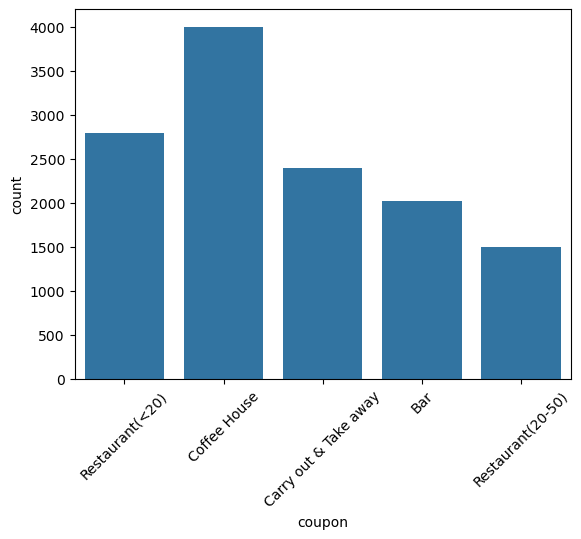

In [68]:
sns.countplot(data=data, x='coupon')
plt.xticks(rotation=45)

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'NotAccepted')

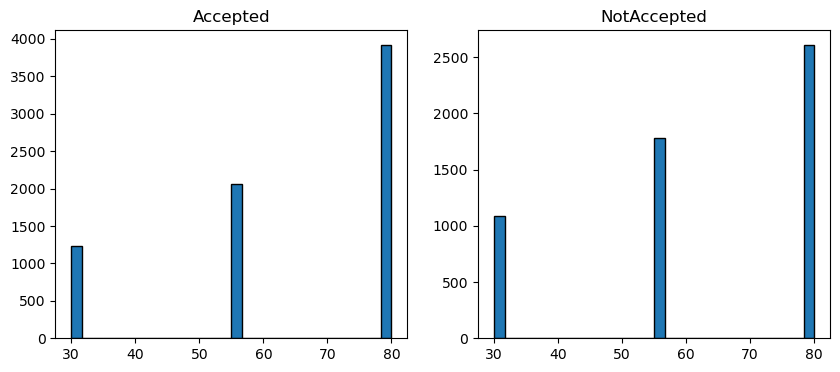

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
couponaccepted=data.query("Y==1")
couponaNOTccepted=data.query("Y!=1")

axes[0].hist(couponaccepted['temperature'], bins=30, edgecolor='black')
axes[0].set_title('Accepted')
axes[1].hist(couponaNOTccepted['temperature'], bins=30, edgecolor='black')
axes[1].set_title('NotAccepted')

#plt.hist(couponaccepted['temperature'], bins=10, alpha=0.5,label='accepted' )
#plt.hist(couponaNOTccepted['temperature'], bins=10, alpha=0.5,label='notaccepted' )

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [88]:
dfbar=data.query("coupon == 'Bar'")
#print(dfbar)

           destination  passanger weather  temperature  time coupon  \
9      No Urgent Place     Kid(s)   Sunny           80  10AM    Bar   
13                Home      Alone   Sunny           55   6PM    Bar   
17                Work      Alone   Sunny           55   7AM    Bar   
24     No Urgent Place  Friend(s)   Sunny           80  10AM    Bar   
35                Home      Alone   Sunny           55   6PM    Bar   
...                ...        ...     ...          ...   ...    ...   
12663  No Urgent Place  Friend(s)   Sunny           80  10PM    Bar   
12664  No Urgent Place  Friend(s)   Sunny           55  10PM    Bar   
12667  No Urgent Place      Alone   Rainy           55  10AM    Bar   
12670  No Urgent Place    Partner   Rainy           55   6PM    Bar   
12682             Work      Alone   Snowy           30   7AM    Bar   

      expiration  gender age      maritalStatus  ...  CoffeeHouse CarryAway  \
9             1d  Female  21  Unmarried partner  ...        never   

2. What proportion of bar coupons were accepted?


In [89]:
(dfbar.query("Y==1").shape[0]) / (dfbar.shape[0])

0.41001487357461575

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [185]:
#dfbar['Bar'].unique()
barlessthn3=['never', 'less1', '1~3']
barmorethn3=['gt8', '4~8']
#print(barlessthn3)

print("count of drivers who went to Bar 3 or fewer times : ",dfbar.query("Bar in @barlessthn3")['Y'].count())
print("count of drivers who went to Bar more then 3 times : ",dfbar.query("Bar in @barmorethn3")['Y'].count())

print("Acceptence rate of those who went to Bar 3 or fewer times : ",dfbar.query("Bar in @barlessthn3")['Y'].mean())
print("Acceptence rate of those who went to Bar more then 3 times : ",dfbar.query("Bar in @barmorethn3")['Y'].mean())


#dfbar.groupby[]

count of drivers who went to Bar 3 or fewer times :  1797
count of drivers who went to Bar more then 3 times :  199
Acceptence rate of those who went to Bar 3 or fewer times :  0.37061769616026713
Acceptence rate of those who went to Bar more then 3 times :  0.7688442211055276


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [233]:
#print(dfbar['age'].unique() )
barmorethn1 = ['1~3', 'gt8', '4~8']
agelessthn25 = ['below21', '21']

#print(dfbar.query("Bar in @barmorethn1 and age not in @agelessthn25")['Y'].sum())
#print(dfbar.query("Bar in @barmorethn1 and age not in @agelessthn25")['Y'].count())
print(dfbar.query("Bar in @barmorethn1 and age not in @agelessthn25")['Y'].mean())
print(dfbar.query("not (Bar in @barmorethn1 and age not in @agelessthn25)")['Y'].mean())


0.6952380952380952
0.33500313087038197


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [236]:
#dfbar.info()
barmorethn1 = ['1~3', 'gt8', '4~8']
#pssngr = ['Kid(s)']
#ocptn = ['Farming Fishing & Forestry']
#dfbar['occupation'].unique()
print(dfbar.query("Bar in @barmorethn1 and passanger != 'Kid(s)' and occupation != 'Farming Fishing & Forestry'")['Y'].mean())
print(dfbar.query("not (Bar in @barmorethn1 and passanger != 'Kid(s)' and occupation != 'Farming Fishing & Forestry')")['Y'].mean())




0.7132486388384754
0.296043656207367


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [252]:
#maritalStatus, RestaurantLessThan20, age, income
barmorethn1 = ['1~3', 'gt8', '4~8']
ageunder30 = ['21','26', 'below21']
chprestmorethn4 = ['4~8', 'gt8']
incomelessthn50k= ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']
#dfbar['income'].unique()
print(dfbar.query("(Bar in @barmorethn1 and passanger != 'Kid(s)' and maritalStatus !='Widowed') or (Bar in @barmorethn1 and age in @ageunder30) or (RestaurantLessThan20 in @chprestmorethn4 and income in @incomelessthn50k)")['Y'].mean())

print("Drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed ")
print(dfbar.query("Bar in @barmorethn1 and passanger != 'Kid(s)' and maritalStatus !='Widowed'")['Y'].mean())
print("Drivers who go to bars more than once a month and are under the age of 30")
print(dfbar.query("Bar in @barmorethn1 and age in @ageunder30")['Y'].mean())
print("go to cheap restaurants more than 4 times a month and income is less than 50K")
print(dfbar.query("Bar in RestaurantLessThan20 in @chprestmorethn4 and income in @incomelessthn50k")['Y'].mean())
#or (Bar in @barmorethn1 and age in @ageunder30) or (RestaurantLessThan20 in @chprestmorethn4 and income in @incomelessthn50k)")['Y'].mean()

#dfbar.info()

0.5889175257731959
Drivers who go to bars more than once a month, had passengers that were not a kid, and were not widowed 
0.7132486388384754
Drivers who go to bars more than once a month and are under the age of 30
0.7217391304347827
Drivers who go to cheap restaurants more than 4 times a month and income is less than 50K
0.45348837209302323


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

The dataset includes more entries from warmer temperatures, and the histograms show that coupon acceptance generally increases as temperatures rise.

For Bar coupons, the overall acceptance rate is 41%. The bigger insight comes from bar‑visiting habits: drivers who go three times or less per month accept at 37.1%, while those who go more than three times per month accept at 76.8%. That’s a major jump.

Drivers over 25 who also visit bars more than once a month have a 69.5% acceptance rate, compared to 33.5% for everyone else. This lower rate makes sense because the “other” group includes younger drivers—some possibly under the legal drinking age—and people who don’t go to bars at all.

The data also shows that drivers under 30 who visit bars more than once a month tend to accept coupons at a high rate. Another small pattern is that parents traveling without a child are more likely to accept Bar coupons.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

I also ran some additional analysis. Companion type and gender by themselves don’t seem to have much impact on acceptance rates. 
Carry‑out and take‑away coupons, however, have the highest acceptance regardless of marital status. 
Coupons with a one‑day expiration are accepted more often. On sunny days, overall acceptance is higher—which fits intuition—but an interesting detail is that cheaper restaurant coupons see the highest acceptance specifically on sunny days.

In [253]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [265]:
data['coupon'].unique()
#data.groupby('CarryAway').size()
print(data.groupby('coupon')['Y'].mean())
print(data.groupby('expiration')['Y'].mean())


coupon
Bar                      0.410015
Carry out & Take away    0.735478
Coffee House             0.499249
Restaurant(20-50)        0.441019
Restaurant(<20)          0.707107
Name: Y, dtype: float64
expiration
1d    0.625582
2h    0.495977
Name: Y, dtype: float64


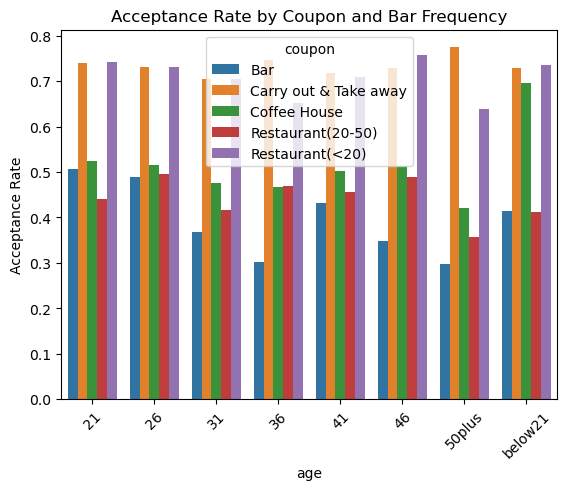

In [271]:
accept_by_multi = data.groupby(['age', 'coupon'])['Y'].mean().reset_index()
sns.barplot(data=accept_by_multi, x='age', y='Y', hue='coupon')
plt.xticks(rotation=45)
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate by Coupon and Bar Frequency')
plt.show()

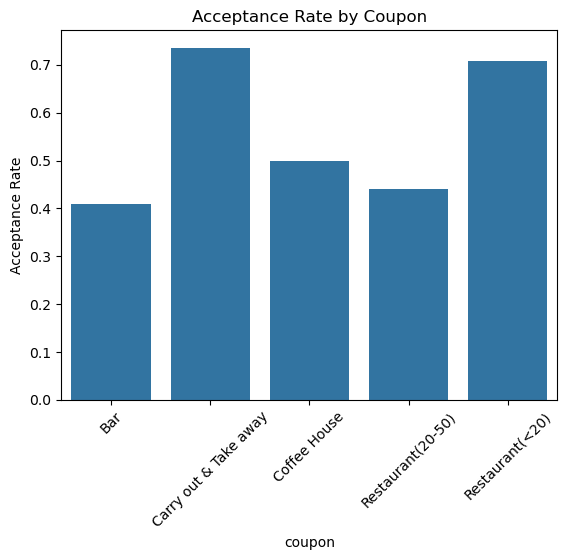

In [277]:
accept_by_coupon = data.groupby('coupon')['Y'].mean().reset_index()
sns.barplot(data=accept_by_coupon, x='coupon', y='Y')
plt.xticks(rotation=45)
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate by Coupon')
plt.show()

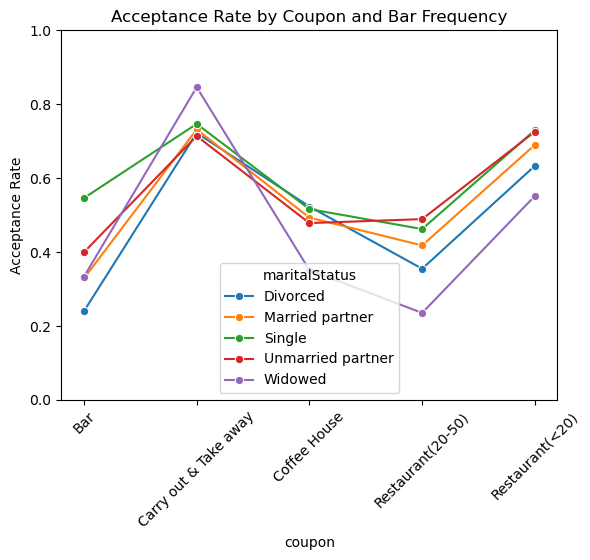

In [280]:
accept_multi = data.groupby(['coupon', 'maritalStatus'])['Y'].mean().reset_index()

sns.lineplot(data=accept_multi, x='coupon', y='Y', hue='maritalStatus', marker='o')

plt.xticks(rotation=45)
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate by Coupon and Bar Frequency')
plt.ylim(0, 1)
plt.show()

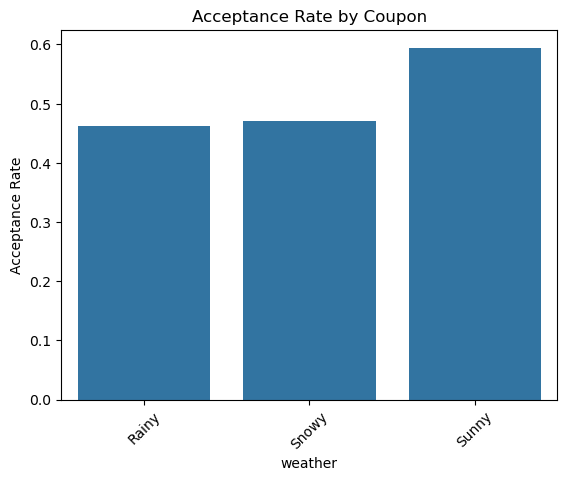

In [281]:
accept_by_coupon = data.groupby('weather')['Y'].mean().reset_index()
sns.barplot(data=accept_by_coupon, x='weather', y='Y')
plt.xticks(rotation=45)
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate by Coupon')
plt.show()

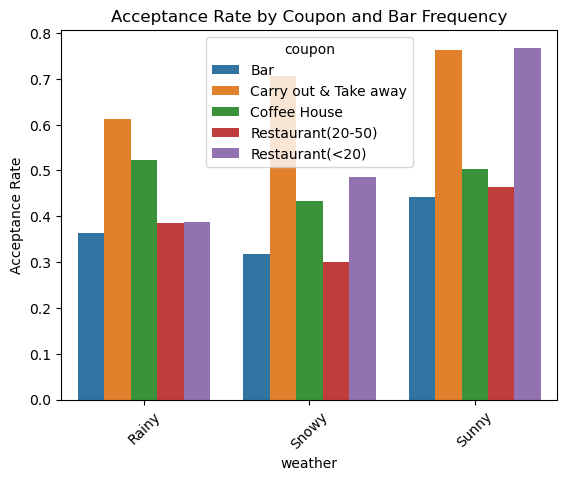

In [282]:
accept_by_multi = data.groupby(['weather', 'coupon'])['Y'].mean().reset_index()
sns.barplot(data=accept_by_multi, x='weather', y='Y', hue='coupon')
plt.xticks(rotation=45)
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate by Coupon and Bar Frequency')
plt.show()